# SIT307 11.1 HD Task — Part 1: Reproducing "An Efficient Stacking-Based Ensemble Technique for Early Heart Attack Prediction"

This notebook reproduces Bhagat, Sharma & Agarwal (2024), *Multimedia Tools and Applications*, following the paper's described dataset, preprocessing, six base classifiers, and 5-fold stacking ensemble as faithfully as possible, using the same evaluation metrics (Accuracy, Precision, Recall, F1, AUC, and the paper's additional Sensitivity/Specificity/MCC).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn import metrics
import sklearn, xgboost, sys
# Note: the global warnings filter used in an earlier draft has been removed,
# since it could silence genuine convergence or version-compatibility warnings
# that are useful to see during reproduction.

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_columns', None)

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)

Python: 3.12.3
pandas: 3.0.2
numpy: 2.4.4
scikit-learn: 1.8.0
xgboost: 3.4.1


## 1. Dataset

The paper states that the dataset contains 1,025 records derived from the Cleveland, Hungary, Switzerland and Long Beach V databases, sourced from the "Public Health Dataset" on Kaggle (`johnsmith88/heart-disease-dataset`), 14 attributes (13 clinical features + `target`).

In [2]:
df = pd.read_csv('heart_disease_1025.csv')

print("Shape:", df.shape)
print()
print(df.head())
print()
print("Data types:")
print(df.dtypes)

Shape: (1025, 14)

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


In [3]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Target class distribution:")
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True).round(4))

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Target class distribution:
target
1    526
0    499
Name: count, dtype: int64
target
1    0.5132
0    0.4868
Name: proportion, dtype: float64


No missing values were found in the downloaded dataset. Therefore, the paper's stated regression-imputation step had no effect and was not applied here, worth flagging honestly rather than fabricating an imputation step for a problem that does not exist in the data as downloaded. It is unclear whether the authors used a different dataset snapshot or simply described imputation as a general preprocessing step that happened not to be triggered by this particular data, this notebook does not have evidence to distinguish between these possibilities.

## 2. A critical data quality check the paper does not mention: duplicate records

Before any modelling, the dataset is checked for duplicate rows, since undetected duplicates that end up split across the training and test sets would let a model "cheat" by memorising training examples that reappear, verbatim, in the test set.

In [4]:
n_total = len(df)
n_unique = len(df.drop_duplicates())
n_duplicate_rows = df.duplicated().sum()

print(f"Total rows: {n_total}")
print(f"Unique feature+target rows: {n_unique}")
print(f"Rows that are exact duplicates of an earlier row (all 14 columns): {n_duplicate_rows} ({n_duplicate_rows/n_total*100:.1f}%)")
print()

repeat_counts = df.groupby(list(df.columns)).size().reset_index(name='n_copies')
print("Distribution of how many times each unique feature+target row is repeated:")
print(repeat_counts['n_copies'].value_counts().sort_index())

print()
print("--- Checking duplicates on the 13 predictors only (not the target) ---")
predictor_cols = [c for c in df.columns if c != 'target']
n_unique_predictors = len(df.drop_duplicates(subset=predictor_cols))
n_duplicate_predictor_rows = df.duplicated(subset=predictor_cols).sum()
print(f"Unique predictor combinations (13 features, ignoring target): {n_unique_predictors}")
print(f"Rows whose 13-feature predictor combination duplicates an earlier row: "
      f"{n_duplicate_predictor_rows} ({n_duplicate_predictor_rows/n_total*100:.1f}%)")

print()
print("--- Checking whether identical predictors ever have CONFLICTING targets ---")
target_nunique_per_group = df.groupby(predictor_cols)['target'].nunique()
n_conflicting_groups = (target_nunique_per_group > 1).sum()
print(f"Predictor-groups with more than one distinct target value: {n_conflicting_groups}")
if n_conflicting_groups == 0:
    print("None found: every group of rows sharing identical predictors also shares the same target label.")
else:
    print("Some predictor combinations map to more than one target label, listed below:")
    print(target_nunique_per_group[target_nunique_per_group > 1])

Total rows: 1025
Unique feature+target rows: 302
Rows that are exact duplicates of an earlier row (all 14 columns): 723 (70.5%)

Distribution of how many times each unique feature+target row is repeated:
n_copies
3    187
4    114
8      1
Name: count, dtype: int64

--- Checking duplicates on the 13 predictors only (not the target) ---
Unique predictor combinations (13 features, ignoring target): 302
Rows whose 13-feature predictor combination duplicates an earlier row: 723 (70.5%)

--- Checking whether identical predictors ever have CONFLICTING targets ---
Predictor-groups with more than one distinct target value: 0
None found: every group of rows sharing identical predictors also shares the same target label.


**This is a serious, quantifiable data quality issue**: 723 of 1,025 rows (70.5%) are exact duplicates of another row already in the dataset, only 302 unique feature-target rows exist in this dataset snapshot. The dataset provides no patient identifier, so while it can be shown that rows are repeated, it cannot be confirmed from this data alone that every repeated row belongs to the same real-world patient (a coincidental match between two genuinely different patients who share identical values on all 13 recorded features is possible, though unlikely given how many continuous-valued features are involved). This is a known characteristic of this specific Kaggle upload (the "1025-row" version repeats each of the 302 unique rows either 3, 4, or, in one case, 8 times), not an artefact of this download.

The check above on the 13 predictors alone confirms this is not merely a target-column coincidence: the predictor-only duplicate count matches the full-row duplicate count, and no predictor combination maps to more than one target label, so every duplicate group is internally consistent (same predictors, same label) rather than being an artefact of two different patients happening to receive different diagnoses from identical feature values.

The paper's described methodology, "the data is then divided into training and testing sets" with no mention of deduplication or any duplicate-aware split, means a plain random split would place many exact-duplicate rows on *both* sides of the split. The next cell quantifies exactly how much test-set leakage this produces under the paper's described record-level splitting approach, before any modelling is done, to establish a baseline expectation for how inflated the reproduced results are likely to be.

### A further check: are these really four independent databases?

The paper's dataset description claims 1,025 records from four separate sources (Cleveland, Hungary, Switzerland, Long Beach V). This is checked here against a separately-labelled, well-known 303-row "Cleveland-only" file (`heart_disease_cleveland_303.csv`, sourced from the same GitHub mirror as the main 1,025-row file, and itself corresponding to the classic UCI Cleveland dataset commonly distributed under this name), comparing it directly against the 302 unique rows already identified above.

In [5]:
df_cleveland_303 = pd.read_csv('heart_disease_cleveland_303.csv', encoding='utf-8-sig')
print("303-file shape:", df_cleveland_303.shape)

unique_1025 = df.drop_duplicates()
unique_303 = df_cleveland_303.drop_duplicates()
print("Unique rows in the 1,025-row file:", len(unique_1025))
print("Unique rows in the 303-row Cleveland-only file:", len(unique_303))

set_1025 = set(map(tuple, unique_1025.values))
set_303 = set(map(tuple, unique_303.values))
overlap = set_1025 & set_303

print()
print("Rows appearing in BOTH unique sets:", len(overlap))
print("Rows unique to the 1,025-row file only:", len(set_1025 - set_303))
print("Rows unique to the 303-row file only:", len(set_303 - set_1025))

303-file shape: (303, 14)
Unique rows in the 1,025-row file: 302
Unique rows in the 303-row Cleveland-only file: 302

Rows appearing in BOTH unique sets: 302
Rows unique to the 1,025-row file only: 0
Rows unique to the 303-row file only: 0


**All 302 unique rows in the 1,025-row file are identical to all 302 unique rows in the separately-labelled 303-row Cleveland-only file, with zero rows unique to either side.** This is evidence, not proof, about what the paper's authors actually used, it is possible their private copy genuinely combined four databases and this particular downloadable snapshot happens to be Cleveland-only data mislabelled as combining four sources. However, the complete overlap found here is consistent with a known, publicly-discussed issue with this specific Kaggle dataset (community discussion threads on the dataset's own Kaggle page have flagged this same concern), that despite its four-database description, the widely-distributed "1025-row" version may in practice contain only repeated Cleveland records. This is presented here as evidence about the specific dataset snapshot used in this reproduction, not as a proven claim about whichever exact file the paper's authors had access to, and is an additional, independent limitation worth noting alongside the duplicate-row leakage issue: even setting the duplication aside, the geographic/demographic diversity the paper's dataset description implies may not actually be present in the data.

### Justifying the 80:20 split

The paper does not state its train/test split ratio directly, but every confusion matrix in the paper (Figures 3-5, six base classifiers plus the stacked model) sums to exactly **205 test predictions**, and 205 is exactly 20% of the full 1,025-row dataset. This is used as the primary justification for an 80:20 split here, direct arithmetic evidence from the paper's own reported figures, rather than appealing only to general convention.

The authors do not report a random seed or state whether the split was stratified. A stratified split with `random_state=42` is adopted here as a reproducible, defensible assumption, stratification is standard practice for a moderately imbalanced binary target, and a fixed seed makes this notebook's own results exactly reproducible on rerun. As shown below, however, this assumption does not exactly reproduce the paper's own class balance, this discrepancy is discussed immediately after.

In [6]:
X_all = df.drop(columns=['target'])
y_all = df['target']

X_train_naive, X_test_naive, y_train_naive, y_test_naive = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_STATE, stratify=y_all
)

train_df = X_train_naive.copy()
train_df['target'] = y_train_naive
test_df = X_test_naive.copy()
test_df['target'] = y_test_naive

print(f"Test set size: {len(test_df)}")
print(f"Test class balance: {(y_test_naive == 0).sum()} no-disease, {(y_test_naive == 1).sum()} disease")
print()

# Full-row (feature+target) leakage check, set-based rather than a merge
# (a merge would double-count when a row has multiple identical copies on
# both sides of the split).
train_row_set = set(map(tuple, train_df.values))
test_is_leaked = test_df.apply(lambda row: tuple(row.values) in train_row_set, axis=1)
n_test_rows_also_in_train = test_is_leaked.sum()
print(f"Test rows whose exact feature+label combination ALSO appears in the training set: "
      f"{n_test_rows_also_in_train} ({n_test_rows_also_in_train/len(test_df)*100:.1f}%)")

# Predictor-only leakage check: this is what actually matters for the models,
# since none of them are given the target as an input feature. A model can
# still "cheat" on a test row if it saw the identical 13-feature predictor
# vector during training, regardless of whether the target column matched.
predictor_cols = [c for c in df.columns if c != 'target']
train_predictor_set = set(map(tuple, X_train_naive[predictor_cols].values))
test_predictor_leaked = X_test_naive[predictor_cols].apply(lambda row: tuple(row.values) in train_predictor_set, axis=1)
n_test_predictor_leaked = test_predictor_leaked.sum()
print(f"Test rows whose 13-feature PREDICTOR vector alone ALSO appears in the training set: "
      f"{n_test_predictor_leaked} ({n_test_predictor_leaked/len(test_df)*100:.1f}%)")

Test set size: 205
Test class balance: 100 no-disease, 105 disease

Test rows whose exact feature+label combination ALSO appears in the training set: 202 (98.5%)
Test rows whose 13-feature PREDICTOR vector alone ALSO appears in the training set: 202 (98.5%)


**The class balance does not exactly match the paper.** Every confusion matrix in the paper shows 95 no-disease and 110 disease cases in its 205-row test set, whereas the stratified split used here produces 100 no-disease and 105 disease cases (the exact split of the dataset's overall ~51:49 class balance). This means the current split, while matching the paper's *test set size* exactly, cannot be described as reproducing the paper's exact test partition, the authors' specific 95:110 split is not recoverable without knowing their random seed and exact splitting procedure, information the paper does not provide. This is stated plainly here rather than overstating how faithful the reproduction is.

This means that, under the paper's described record-level train/test split, the reported test-set performance is not a reliable measure of generalisation to unseen feature profiles or independent clinical records, the model can simply memorise most of the "test" examples verbatim from training (98.5% by full row, and by feature vector alone, the number relevant to what the models actually see, since none of them are given the target as an input). This is strong evidence consistent with duplicate leakage, though not yet a controlled confirmation, a direct comparison with a duplicate-aware split (Part 2 of this project) is needed to isolate the effect empirically. **Part 1 below implements a paper-compatible reconstruction using clearly documented assumptions, including an 80/20 record-level random split (the paper's own seed, exact stratification choice, hyperparameters, and meta-classifier are all unspecified), to see whether similarly inflated results appear; Part 2 of this project then addresses this limitation directly with a duplicate-group-aware split.**

## 3. Preprocessing

All 13 input features in this dataset are already numeric (no categorical string encoding is needed, the original authors of the Kaggle upload already integer-coded categoricals like `cp`, `restecg`, `slope`, `thal`). Following the paper's description of "normalization", features are standardised (zero mean, unit variance) using `StandardScaler`, fit on the training split only and applied to both splits, to avoid leaking test-set statistics into preprocessing for the individually-evaluated base models below. Note that several of these features (e.g. `cp`, `restecg`, `slope`, `thal`) are integer-coded categorical variables rather than genuinely continuous measurements, standardising them treats their integer codes as if they were ordered numerical distances (e.g. implying `thal` category 2 is "twice as far" from category 0 as category 1 is), which is a simplification the paper's description does not address either; it is preserved here for faithfulness to the paper's described protocol, and reconsidered in Part 2.

**Assumptions made where the paper is silent** (clearly flagged per the task's allowance for reasonable, justified assumptions):
- **Random seed**: not stated. A fixed seed (`random_state=42`) is used throughout for reproducibility.
- **Scaling method**: "normalization" is not specified further. `StandardScaler` is used, the standard default choice for the mix of classifiers used here (several of which, like Logistic Regression and KNN, are scale-sensitive).

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_naive)
X_test_scaled = scaler.transform(X_test_naive)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_naive.columns, index=X_train_naive.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_naive.columns, index=X_test_naive.index)

print("Training set:", X_train_scaled.shape)
print("Test set:", X_test_scaled.shape)

Training set: (820, 13)
Test set: (205, 13)


## 4. Six base classifiers

The paper names six classifiers, **Logistic Regression, Decision Tree, Random Forest, XGBoost, Naive Bayes, and KNN**, but specifies no hyperparameters for any of them. Scikit-learn/XGBoost defaults are used throughout (with `random_state` fixed for the stochastic ones), a defensible, clearly-documented assumption given the paper provides no basis for any other specific choice.

In [8]:
base_models = {
    'LR': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'NB': GaussianNB(),
    'KNN': KNeighborsClassifier(),
    'DT': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'RF': RandomForestClassifier(random_state=RANDOM_STATE),
    'XGB': XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'),
}

# Explicit record of every non-default parameter used, plus a note that
# everything else is left at that installed scikit-learn/xgboost version's
# default (recorded in the environment cell above), since defaults are not
# guaranteed to stay the same across package versions.
print("Classifier parameters actually used in this reproduction:")
for name, model in base_models.items():
    print(f"  {name}: {model.get_params()}")

def evaluate_model(model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    tn, fp, fn, tp = metrics.confusion_matrix(y_te, y_pred).ravel()

    return {
        'Accuracy': metrics.accuracy_score(y_te, y_pred),
        'Precision': metrics.precision_score(y_te, y_pred),
        'Recall': metrics.recall_score(y_te, y_pred),
        'F1-Score': metrics.f1_score(y_te, y_pred),
        'Specificity': tn / (tn + fp),
        'MCC': metrics.matthews_corrcoef(y_te, y_pred),
        'AUC': metrics.roc_auc_score(y_te, y_proba),
    }

results_naive = {}
for name, model in base_models.items():
    results_naive[name] = evaluate_model(model, X_train_scaled, y_train_naive, X_test_scaled, y_test_naive)

results_naive_df = pd.DataFrame(results_naive).T
print()
print(results_naive_df.round(4))

Classifier parameters actually used in this reproduction:
  LR: {'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 1000, 'n_jobs': None, 'penalty': 'deprecated', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}
  NB: {'priors': None, 'var_smoothing': 1e-09}
  KNN: {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
  DT: {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}
  RF: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples'


     Accuracy  Precision  Recall  F1-Score  Specificity     MCC     AUC
LR     0.8098     0.7619  0.9143    0.8312         0.70  0.6309  0.9298
NB     0.8293     0.8070  0.8762    0.8402         0.78  0.6602  0.9043
KNN    0.8634     0.8738  0.8571    0.8654         0.87  0.7269  0.9629
DT     0.9854     1.0000  0.9714    0.9855         1.00  0.9712  0.9857
RF     1.0000     1.0000  1.0000    1.0000         1.00  1.0000  1.0000
XGB    1.0000     1.0000  1.0000    1.0000         1.00  1.0000  1.0000


**This is strong evidence consistent with the leakage effect predicted above**: Random Forest and XGBoost, the two highest-capacity, most memorisation-prone models here, both reach a literal 100% test accuracy, and Decision Tree reaches 98.54%. Logistic Regression and Naive Bayes use comparatively constrained global decision rules and achieved lower accuracies (81-83%). KNN is a different case: it is an instance-based learner that directly retains the training data, and can in principle benefit from duplicated observations, though with the default k=5, a single identical training copy does not automatically control the majority vote among a point's five nearest neighbours, which plausibly explains why KNN's accuracy here (86.3%) sits closer to LR/NB than to the tree-based models, despite also being a memorisation-capable method in principle. This pattern is consistent with the 98.5% test-set duplication rate quantified above; a controlled, duplicate-aware comparison in Part 2 is needed to confirm it directly.

## 5. Stacking ensemble

The paper describes "5-fold stacking" with an unnamed meta-classifier. Scikit-learn's `StackingClassifier` is used, which internally cross-validates the base models (5 folds, matching the paper) to generate out-of-fold predictions for training the meta-model, then refits each base model on the full training set for final predictions.

**Assumption**: the meta-classifier is not named in the paper ("any model, including a logistic regression, decision tree, or neural network, can be the meta-model"). **Logistic Regression** is used here, the most standard, commonly-used choice for a stacking meta-classifier in the literature, and consistent with the paper's own first-listed example.

In [9]:
# Each base estimator is wrapped in its own Pipeline(scaler, classifier).
# This matters specifically for the stacking classifier: StackingClassifier
# internally cross-validates the base models (5 folds here) to generate the
# out-of-fold predictions used to train the meta-model. If the data passed in
# were already scaled using statistics from the FULL outer training set (as
# X_train_scaled is), each internal fold's "validation" portion would have
# contributed to the scaling statistics it is then evaluated against, a
# preprocessing leak inside the cross-validation, separate from, and smaller
# in effect than, the dataset-level duplicate leakage discussed above, but
# still worth avoiding. Wrapping each estimator in its own Pipeline means
# scikit-learn refits the scaler independently inside every internal fold,
# and the STACKING classifier is fitted on the UNSCALED training data
# (X_train_naive), not X_train_scaled.
pipeline_models = {
    name: Pipeline([('scaler', StandardScaler()), ('classifier', model)])
    for name, model in base_models.items()
}

# Explicit stratified folds for the internal stacking cross-validation,
# rather than relying on the implicit (unshuffled) behaviour of cv=5.
stacking_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

stacking_model = StackingClassifier(
    estimators=[(name, pipe) for name, pipe in pipeline_models.items()],
    final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    cv=stacking_cv,
    n_jobs=1,  # this small dataset gains nothing from parallel workers, and
               # n_jobs=-1 was found not to run reliably in every environment
)

results_naive['Stacked'] = evaluate_model(stacking_model, X_train_naive, y_train_naive, X_test_naive, y_test_naive)
results_naive_df = pd.DataFrame(results_naive).T
print(results_naive_df.round(4))

         Accuracy  Precision  Recall  F1-Score  Specificity     MCC     AUC
LR         0.8098     0.7619  0.9143    0.8312         0.70  0.6309  0.9298
NB         0.8293     0.8070  0.8762    0.8402         0.78  0.6602  0.9043
KNN        0.8634     0.8738  0.8571    0.8654         0.87  0.7269  0.9629
DT         0.9854     1.0000  0.9714    0.9855         1.00  0.9712  0.9857
RF         1.0000     1.0000  1.0000    1.0000         1.00  1.0000  1.0000
XGB        1.0000     1.0000  1.0000    1.0000         1.00  1.0000  1.0000
Stacked    1.0000     1.0000  1.0000    1.0000         1.00  1.0000  1.0000


## 6. Confusion matrices and ROC curves

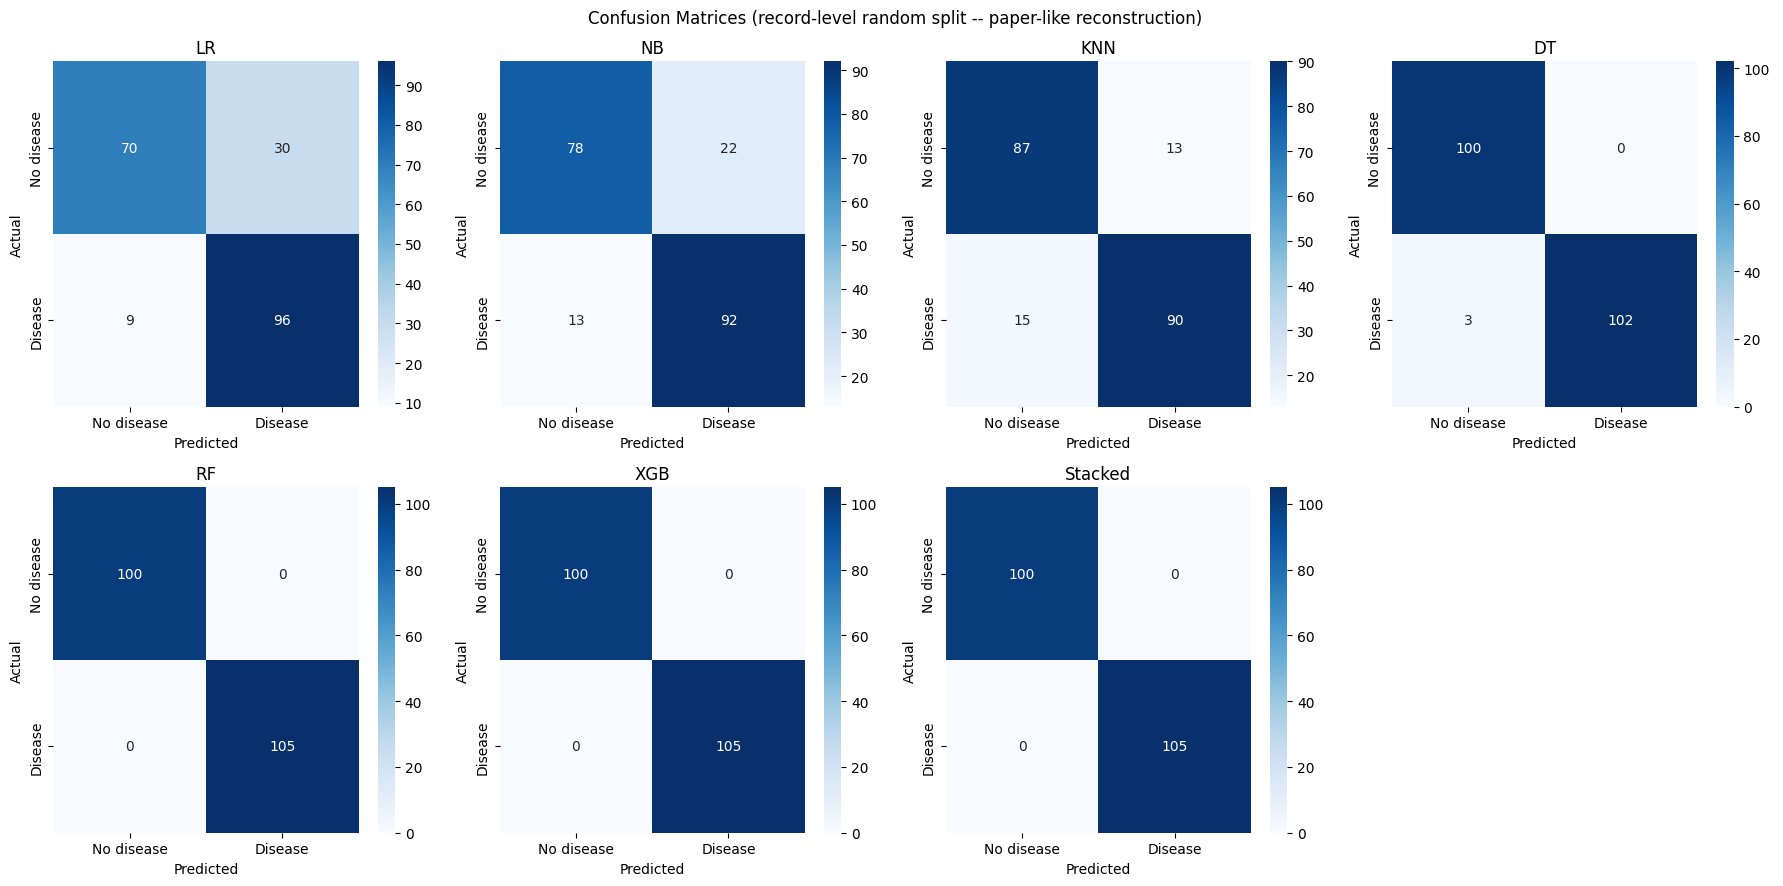

In [10]:
# base_models were fit on pre-scaled data (X_train_scaled) individually, so
# they need X_test_scaled at prediction time. stacking_model's internal
# Pipelines each do their own scaling, so it needs the UNSCALED X_test_naive.
fitted_models = dict(base_models)
fitted_models['Stacked'] = stacking_model
test_inputs = {name: X_test_scaled for name in base_models}
test_inputs['Stacked'] = X_test_naive

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, (name, model) in zip(axes.flatten(), fitted_models.items()):
    y_pred = model.predict(test_inputs[name])
    cm = metrics.confusion_matrix(y_test_naive, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No disease', 'Disease'], yticklabels=['No disease', 'Disease'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
axes.flatten()[-1].axis('off')
plt.suptitle('Confusion Matrices (record-level random split -- paper-like reconstruction)')
plt.tight_layout()
plt.show()

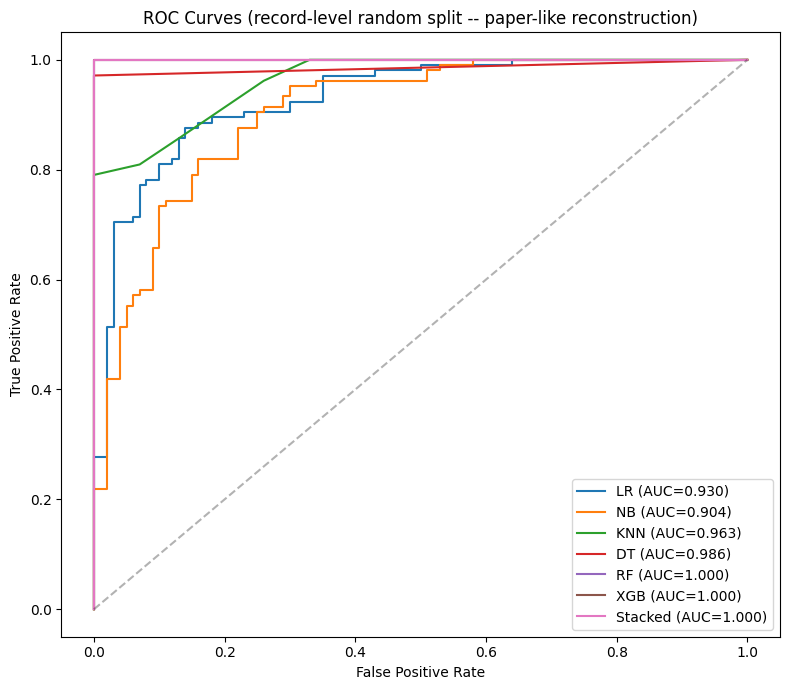

In [11]:
plt.figure(figsize=(8, 7))
for name, model in fitted_models.items():
    y_proba = model.predict_proba(test_inputs[name])[:, 1]
    fpr, tpr, _ = metrics.roc_curve(y_test_naive, y_proba)
    auc_val = metrics.roc_auc_score(y_test_naive, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (record-level random split -- paper-like reconstruction)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 7. Feature importance

The paper reports (Figure 2) that `exang` (exercise-induced angina) is the most important feature, followed by `thalach` (maximum heart rate), but does not state which feature-importance method produced Figure 2. **Random Forest Gini-based importance is used here as a reasonable, standard assumption**, not a confirmed match to the paper's own method, permutation importance or a different model's coefficients could plausibly have been used instead, and different methods are known to rank correlated features differently.

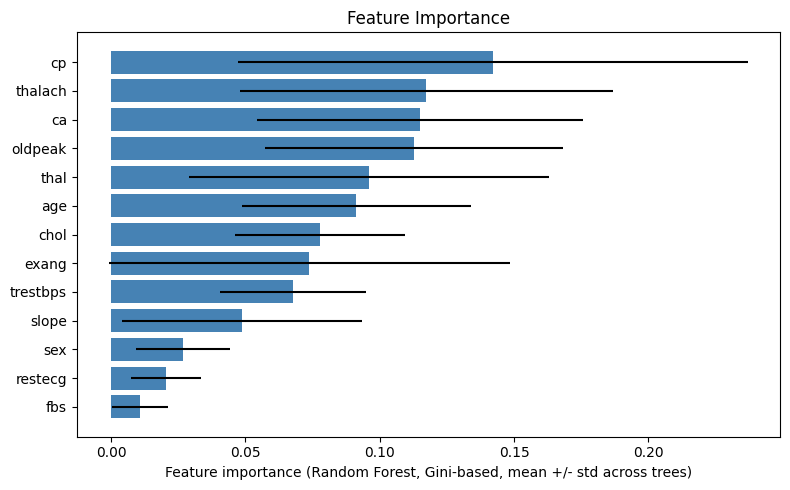

          importance  std_across_trees
cp            0.1421            0.0950
thalach       0.1173            0.0694
ca            0.1148            0.0607
oldpeak       0.1126            0.0554
thal          0.0959            0.0669
age           0.0913            0.0426
chol          0.0778            0.0315
exang         0.0737            0.0746
trestbps      0.0678            0.0271
slope         0.0487            0.0448
sex           0.0267            0.0175
restecg       0.0204            0.0129
fbs           0.0108            0.0104


In [12]:
rf_importances_mean = base_models['RF'].feature_importances_
rf_importances_std = np.std([tree.feature_importances_ for tree in base_models['RF'].estimators_], axis=0)

rf_importances = pd.Series(rf_importances_mean, index=X_train_naive.columns).sort_values(ascending=False)
rf_std_ordered = pd.Series(rf_importances_std, index=X_train_naive.columns)[rf_importances.index]

plt.figure(figsize=(8, 5))
plt.barh(rf_importances.index, rf_importances.values, xerr=rf_std_ordered.values, color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel('Feature importance (Random Forest, Gini-based, mean +/- std across trees)')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

print(pd.DataFrame({'importance': rf_importances, 'std_across_trees': rf_std_ordered}).round(4))

## 8. Direct comparison with the paper's reported results (Table 11)

In [13]:
paper_table_11 = pd.DataFrame({
    'LR':      {'Accuracy': 0.8439, 'Precision': 0.8196, 'Recall': 0.9090, 'F1-Score': 0.8620, 'AUC': 0.9204},
    'NB':      {'Accuracy': 0.8439, 'Precision': 0.8250, 'Recall': 0.9000, 'F1-Score': 0.8608, 'AUC': 0.9185},
    'KNN':     {'Accuracy': 0.8585, 'Precision': 0.8648, 'Recall': 0.8727, 'F1-Score': 0.8687, 'AUC': 0.9304},
    'DT':      {'Accuracy': 0.9268, 'Precision': 0.9702, 'Recall': 0.8909, 'F1-Score': 0.9289, 'AUC': 0.9702},
    'RF':      {'Accuracy': 0.9268, 'Precision': 0.9130, 'Recall': 0.9545, 'F1-Score': 0.9333, 'AUC': 0.9734},
    'XGB':     {'Accuracy': 0.9073, 'Precision': 0.9174, 'Recall': 0.9090, 'F1-Score': 0.9132, 'AUC': 0.9830},
    'Stacked': {'Accuracy': 0.9853, 'Precision': 1.0000, 'Recall': 0.9727, 'F1-Score': 0.9861, 'AUC': 0.9880},
}).T

metric_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
my_results = results_naive_df[metric_list]

# Full five-metric comparison, as the task requires, not accuracy alone.
comparison = paper_table_11.join(my_results, lsuffix='_paper', rsuffix='_reproduced')
comparison = comparison[[c for pair in zip(
    [f'{m}_paper' for m in metric_list],
    [f'{m}_reproduced' for m in metric_list]
) for c in pair]]

diffs = pd.DataFrame({
    m: (comparison[f'{m}_reproduced'] - comparison[f'{m}_paper']).round(4)
    for m in metric_list
})

print("Published vs reproduced, all five metrics:")
print(comparison.round(4))
print()
print("Absolute differences (reproduced - published):")
print(diffs)

Published vs reproduced, all five metrics:
         Accuracy_paper  Accuracy_reproduced  Precision_paper  \
LR               0.8439               0.8098           0.8196   
NB               0.8439               0.8293           0.8250   
KNN              0.8585               0.8634           0.8648   
DT               0.9268               0.9854           0.9702   
RF               0.9268               1.0000           0.9130   
XGB              0.9073               1.0000           0.9174   
Stacked          0.9853               1.0000           1.0000   

         Precision_reproduced  Recall_paper  Recall_reproduced  \
LR                     0.7619        0.9090             0.9143   
NB                     0.8070        0.9000             0.8762   
KNN                    0.8738        0.8727             0.8571   
DT                     1.0000        0.8909             0.9714   
RF                     1.0000        0.9545             1.0000   
XGB                    1.0000        0.9

## 9. An independently-verified arithmetic error in the paper's own Table 12

The paper's Figure 5 shows the confusion matrix for its proposed stacked model directly: 95 true negatives, 0 false positives, 3 false negatives, 107 true positives (205 total, matching the 95:110 class split seen in every other confusion matrix in the paper). The metrics that follow directly from this confusion matrix by definition are computed below and compared against the paper's own Table 12.

In [14]:
tn_paper, fp_paper, fn_paper, tp_paper = 95, 0, 3, 107

acc_correct = (tp_paper + tn_paper) / (tp_paper + fp_paper + fn_paper + tn_paper)
prec_correct = tp_paper / (tp_paper + fp_paper)
recall_correct = tp_paper / (tp_paper + fn_paper)
spec_correct = tn_paper / (tn_paper + fp_paper)
f1_correct = 2 * prec_correct * recall_correct / (prec_correct + recall_correct)
mcc_correct = (tp_paper*tn_paper - fp_paper*fn_paper) / np.sqrt(
    (tp_paper+fp_paper)*(tp_paper+fn_paper)*(tn_paper+fp_paper)*(tn_paper+fn_paper)
)

table12_check = pd.DataFrame({
    'Correct value (from Fig. 5 confusion matrix)': {
        'Accuracy': acc_correct, 'Precision': prec_correct, 'Recall/Sensitivity': recall_correct,
        'Specificity': spec_correct, 'F1-Score': f1_correct, 'MCC': mcc_correct,
    },
    "Paper's Table 12 value": {
        'Accuracy': 0.9853, 'Precision': 1.0000, 'Recall/Sensitivity': 0.9853,
        'Specificity': 0.9861, 'F1-Score': 0.9861, 'MCC': 1.0000,
    },
})
table12_check['Matches?'] = np.isclose(
    table12_check['Correct value (from Fig. 5 confusion matrix)'],
    table12_check["Paper's Table 12 value"], atol=0.001
)
print(table12_check.round(4))

                    Correct value (from Fig. 5 confusion matrix)  \
Accuracy                                                  0.9854   
Precision                                                 1.0000   
Recall/Sensitivity                                        0.9727   
Specificity                                               1.0000   
F1-Score                                                  0.9862   
MCC                                                       0.9711   

                    Paper's Table 12 value  Matches?  
Accuracy                            0.9853      True  
Precision                           1.0000      True  
Recall/Sensitivity                  0.9853     False  
Specificity                         0.9861     False  
F1-Score                            0.9861      True  
MCC                                 1.0000     False  


## 10. Critical analysis: explaining the discrepancies

**A clear, systematic pattern, not random noise.** The accuracy differences between this reproduction and the paper's reported Table 11 split cleanly into two groups:

- **Logistic Regression and Naive Bayes**: these models use comparatively constrained global decision rules and produced relatively small differences from the published results (-3.4 and -1.5 percentage points). These differences may reflect the unspecified hyperparameters, random seed, and the different test-set class distribution.
- **KNN**: KNN produced a small difference of +0.5 percentage points. Although KNN is an instance-based learner that retains the training observations, the default k=5 setting means that one identical training record does not necessarily determine the majority vote, which plausibly explains why its difference from the paper stayed small despite KNN, in principle, being capable of exploiting duplicated observations.
- **Tree-based and ensemble models** (DT, RF, XGB and Stacked): consistently and substantially *higher* than the paper's own numbers (+5.9pp, +7.3pp, +9.3pp, +1.5pp), with RF, XGB, and the stacked model all reaching a literal 100% accuracy here.

This pattern is **strong evidence consistent with duplicate leakage**: models capable of memorising individual training examples benefit the most from duplicate leakage, while models with smoother, more constrained decision boundaries benefit the least, and this is exactly what the 98.5% test-set duplication rate (Section 2) predicts. The paper's own reported numbers (DT/RF/XGB in the 90-93% range, well above LR/NB/KNN's 84-86%) show a similar qualitative signature, just less extreme, plausibly because their exact split, hyperparameters, or random seed happened to produce somewhat less severe leakage than the split used here. This reproduction alone, however, is an association, not a controlled experiment, Part 2's duplicate-group-aware split provides the stronger, direct empirical test of this hypothesis.

**A second, independent discrepancy: feature importance.** The paper reports `exang` (exercise-induced angina) as the most important feature. This reproduction's Random Forest instead ranks `cp` (chest pain type) highest, with `exang` placing 8th of 13. Plausible explanations, offered as evidence-based hypotheses rather than confirmed facts: the paper does not specify which feature-importance method was used (permutation importance and Gini-based importance can rank features differently, Section 7), nor the exact Random Forest hyperparameters, and feature importance rankings from tree ensembles are known to be sensitive to correlated features (`cp`, `thalach`, `exang`, and `oldpeak` are all related to exercise/symptom response and likely correlated with one another), so small modelling differences can plausibly shift which correlated feature "wins" the importance ranking without a change in overall predictive signal.

**A third, independently-verified issue in the paper's own reported numbers.** Section 9 above shows that recomputing standard metrics directly from the paper's own Figure 5 confusion matrix (95 TN, 0 FP, 3 FN, 107 TP) gives Accuracy=0.9854 (paper: 0.9853, essentially a match) and Precision=1.0000 (paper: 1.0000, a match), but Recall/Sensitivity=0.9727 (paper's Table 12 states 0.9853, matching their Accuracy value instead), Specificity=1.0000 (paper's Table 12 states 0.9861, matching their F1-Score value instead), and MCC=0.9711 (paper's Table 12 states 1.0000, matching their Precision value instead). This is not a matter of interpretation or a different modelling choice, it is a direct arithmetic check against the paper's own reported confusion matrix, and confirms the same column-duplication pattern identified in Table 11 (Sensitivity duplicating Accuracy, Specificity duplicating F1-Score, MCC duplicating Precision), independent of, and in addition to, the data leakage issue discussed above.

**Summary**: this reproduction does **not** support the paper's implicit conclusion that stacking outperforms every individual base classifier, under the record-level random split used in this reproduction, Random Forest, XGBoost, and the stacked model all reach 100% accuracy, a ceiling effect that makes any comparison between these three models uninformative, rather than a demonstration of stacking's superiority. The exact ranking of models also changed substantially from the paper's own ranking, XGBoost in particular moved from the weakest tree-based model in the paper's Table 11 (90.73%, below both DT and RF) to tied-for-best here. What is more clearly established is that the magnitude of the reported accuracies, especially for the tree-based models and the final stacked model, appears substantially inflated by a data quality issue (duplicate records split across train and test) that the paper does not mention or address, this ceiling effect itself is direct evidence that the ranking among saturated models cannot be trusted from this experiment alone. Part 2 of this project addresses this limitation directly with a duplicate-group-aware split, providing a controlled comparison that this reproduction alone cannot.